<a href="https://colab.research.google.com/github/Shawaiz-Project/Data-Analyst/blob/main/02_Day_Corona_Virus_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# COVID-19 Global Data Analysis and Forecasting
## Comprehensive Analysis Report

**Authors**: Shawaiz Ali Data Scientist

**Date**: 2026

This notebook performs a complete analysis of COVID-19 data, including exploratory data analysis, visualization, time series forecasting, and machine learning modeling.

## 1. Environment Setup and Library Imports

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import plotly
import plotly.graph_objs as go
import plotly.express as px
from plotly.subplots import make_subplots
import folium
from folium.plugins import HeatMap

# Statistics
import itertools
from scipy import stats
from scipy.special import boxcox, inv_boxcox
from scipy.optimize import curve_fit

# Time series and forecasting
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Prophet (optional: install with `pip install prophet`)
try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
except ImportError:
    PROPHET_AVAILABLE = False
    print("Prophet not installed. Install with: pip install prophet")

# Machine learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

# Display options
pd.set_option('display.float_format', lambda x: '%.f' % x)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Plot style
sns.set(context='paper', style='ticks', palette='inferno')
sns.mpl.rc("figure", figsize=(12, 6))
mpl.rcParams['figure.dpi'] = 150
plotly.offline.init_notebook_mode(connected=True)

print("All libraries imported successfully.")

All libraries imported successfully.


## 2. Data Loading and Initial Exploration

In [2]:
# Load data
df = pd.read_csv('/content/covid_19_clean_complete.csv')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# Data types
df.info()

# Missing values
missing = df.isnull().sum()
print("\nMissing values:")
print(missing[missing > 0])

Dataset shape: (5822, 8)
Columns: ['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed', 'Deaths', 'Recovered']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5822 entries, 0 to 5821
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  3075 non-null   object 
 1   Country/Region  5822 non-null   object 
 2   Lat             5822 non-null   float64
 3   Long            5822 non-null   float64
 4   Date            5822 non-null   object 
 5   Confirmed       5822 non-null   int64  
 6   Deaths          5822 non-null   int64  
 7   Recovered       5822 non-null   int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 364.0+ KB

Missing values:
Province/State    2747
dtype: int64


In [3]:
# Data cleaning function
def clean_covid_data(df):
    """
    Clean the COVID-19 dataset.

    Parameters:
    -----------
    df : pandas.DataFrame
        Raw data

    Returns:
    --------
    pandas.DataFrame
        Cleaned data
    """
    df_clean = df.copy()

    # 1. Convert date
    df_clean['Date'] = pd.to_datetime(df_clean['Date'])

    # 2. Standardize country names
    country_mapping = {
        'Mainland China': 'China',
        'Others': 'Ship Diamond Princess',
        'US': 'United States'
    }
    df_clean['Country/Region'] = df_clean['Country/Region'].replace(country_mapping)

    # 3. Fill missing Province/State
    df_clean['Province/State'] = df_clean['Province/State'].fillna('NA')

    # 4. Feature engineering
    df_clean['Death_Rate'] = (df_clean['Deaths'] / df_clean['Confirmed'] * 100).fillna(0)
    df_clean['Recovery_Rate'] = (df_clean['Recovered'] / df_clean['Confirmed'] * 100).fillna(0)
    df_clean['Active'] = df_clean['Confirmed'] - df_clean['Deaths'] - df_clean['Recovered']
    df_clean['Active'] = df_clean['Active'].clip(lower=0)

    return df_clean

# Execute cleaning
df = clean_covid_data(df)
print("Data cleaning completed.")
df.head()

Data cleaning completed.


,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Death_Rate,Recovery_Rate,Active
0,Anhui,China,32,117,2020-01-22,1,0,0,0,0,1
1,Beijing,China,40,116,2020-01-22,14,0,0,0,0,14
2,Chongqing,China,30,108,2020-01-22,6,0,0,0,0,6
3,Fujian,China,26,118,2020-01-22,1,0,0,0,0,1
4,Gansu,China,36,104,2020-01-22,0,0,0,0,0,0


## 3. Global Overview

In [6]:
# Global daily aggregates
df_global = df.groupby('Date').agg({
    'Confirmed': 'sum',
    'Deaths': 'sum',
    'Recovered': 'sum',
    'Active': 'sum'
}).reset_index()

# Daily new cases
for col in ['Confirmed', 'Deaths', 'Recovered']:
    df_global[f'New_{col}'] = df_global[col].diff().fillna(0).clip(lower=0)

# Growth rate
df_global['Growth_Rate'] = df_global['Confirmed'].pct_change().fillna(0) * 100

print("Latest global figures:")
df_global.tail(1)

Latest global figures:


,Date,Confirmed,Deaths,Recovered,Active,New_Confirmed,New_Deaths,New_Recovered,Growth_Rate
40,2020-03-02,90313,3085,45604,41624,1942,89,2888,2


In [13]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Global trends - multi-panel plot
fig = make_subplots(rows=2, cols=2,
                    subplot_titles=('Cumulative Confirmed & Deaths', 'Daily New Cases',
                                   'Recovered vs Active', 'Daily Growth Rate'))

# Panel 1: Cumulative
fig.add_trace(go.Scatter(x=df_global['Date'], y=df_global['Confirmed'],
                         name='Confirmed', line=dict(color='blue')), row=1, col=1)
fig.add_trace(go.Scatter(x=df_global['Date'], y=df_global['Deaths'],
                         name='Deaths', line=dict(color='red')), row=1, col=1)

# Panel 2: Daily new confirmed
fig.add_trace(go.Bar(x=df_global['Date'], y=df_global['New_Confirmed'],
                     name='New Confirmed', marker_color='orange'), row=1, col=2)

# Panel 3: Recovered vs Active
fig.add_trace(go.Scatter(x=df_global['Date'], y=df_global['Recovered'],
                         name='Recovered', line=dict(color='green')), row=2, col=1)
fig.add_trace(go.Scatter(x=df_global['Date'], y=df_global['Active'],
                         name='Active', line=dict(color='purple')), row=2, col=1)

# Panel 4: Growth rate
fig.add_trace(go.Scatter(x=df_global['Date'], y=df_global['Growth_Rate'],
                         name='Growth Rate (%)', line=dict(color='red')), row=2, col=2)

fig.update_layout(height=800, title_text="Global COVID-19 Trends")
display(fig)

## 4. Country-Level Analysis

In [9]:
# Latest data per country
latest_date = df['Date'].max()
df_latest = df[df['Date'] == latest_date].groupby('Country/Region').agg({
    'Confirmed': 'sum',
    'Deaths': 'sum',
    'Recovered': 'sum',
    'Active': 'sum'
}).reset_index()

df_latest['Death_Rate'] = (df_latest['Deaths'] / df_latest['Confirmed'] * 100).fillna(0)
df_latest['Recovery_Rate'] = (df_latest['Recovered'] / df_latest['Confirmed'] * 100).fillna(0)
df_latest = df_latest.sort_values('Confirmed', ascending=False)

print(f"Latest date: {latest_date}")
print("\nTop 10 most affected countries:")
df_latest.head(10)

Latest date: 2020-03-02 00:00:00

Top 10 most affected countries:


,Country/Region,Confirmed,Deaths,Recovered,Active,Death_Rate,Recovery_Rate
13,China,80026,2912,44810,32304,4,56
64,South Korea,4335,28,30,4277,1,1
34,Italy,2036,52,149,1835,3,7
30,Iran,1501,66,291,1144,4,19
62,Ship Diamond Princess,705,6,10,689,1,1
35,Japan,274,6,32,236,2,12
22,France,191,3,12,176,2,6
24,Germany,159,0,16,143,0,10
65,Spain,120,0,2,118,0,2
63,Singapore,108,0,78,30,0,72


In [26]:
# Trend comparison for top 15 countries
top_countries = df_latest.head(15)['Country/Region'].tolist()
df_top = df[df['Country/Region'].isin(top_countries)]
df_top_agg = df_top.groupby(['Date', 'Country/Region'])['Confirmed'].sum().reset_index()

fig = px.line(df_top_agg, x='Date', y='Confirmed', color='Country/Region',
              title='Confirmed Cases Trend - Top 15 Countries',
              labels={'Confirmed': 'Cumulative Cases', 'Date': 'Date'})
fig.show()

In [12]:
# Choropleth map
fig = px.choropleth(df_latest,
                    locations='Country/Region',
                    locationmode='country names',
                    color='Confirmed',
                    hover_name='Country/Region',
                    hover_data=['Deaths', 'Recovered', 'Death_Rate'],
                    color_continuous_scale='Reds',
                    title='Global COVID-19 Confirmed Cases',
                    labels={'Confirmed': 'Total Cases'})
fig.update_layout(height=600)
fig.show()

## 5. Time Series Analysis and Forecasting

In [14]:
# 5.1 Stationarity test (ADF)
def adf_test(series, title=''):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'ADF Test - {title}:')
    print(f'  Statistic: {result[0]:.4f}')
    print(f'  p-value: {result[1]:.4f}')
    print(f'  Critical values:')
    for key, value in result[4].items():
        print(f'    {key}: {value:.4f}')
    print(f'  Conclusion: {"Stationary" if result[1] < 0.05 else "Non-stationary"}')
    return result

adf_test(df_global['Confirmed'], 'Global Confirmed')

ADF Test - Global Confirmed:
  Statistic: -0.3586
  p-value: 0.9168
  Critical values:
    1%: -3.6056
    5%: -2.9371
    10%: -2.6070
  Conclusion: Non-stationary


(np.float64(-0.35857889215070116),
 np.float64(0.9167883036277416),
 0,
 40,
 {'1%': np.float64(-3.6055648906249997),
  '5%': np.float64(-2.937069375),
  '10%': np.float64(-2.606985625)},
 np.float64(557.9271924912504))

Global Prophet forecast:


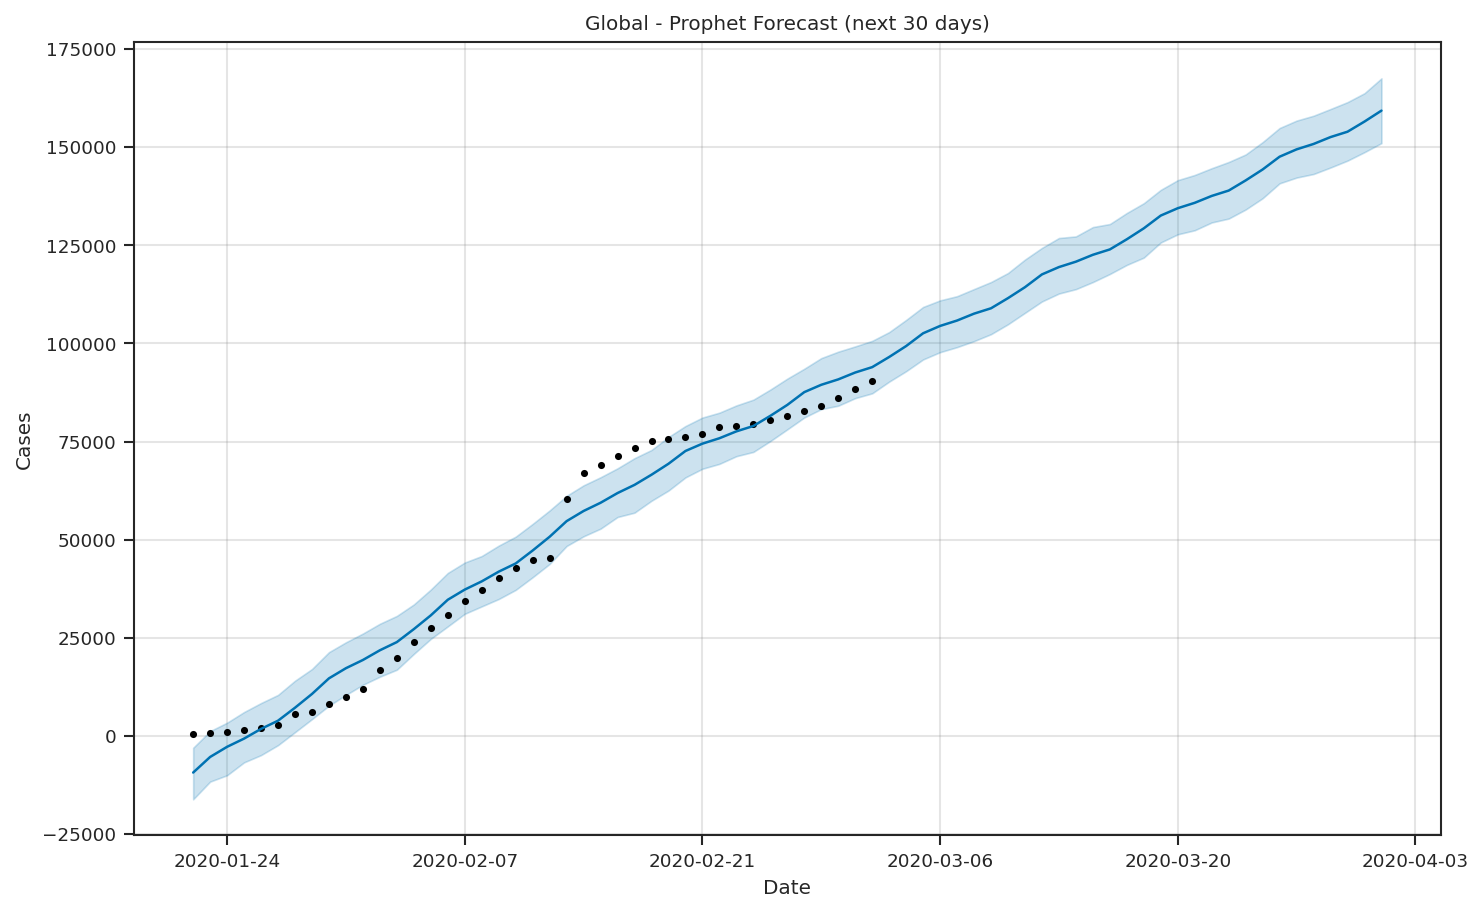

           ds   yhat  yhat_lower  yhat_upper
41 2020-03-03  96554       90275      102898
42 2020-03-04  99342       92934      105999
43 2020-03-05 102598       95925      109302
44 2020-03-06 104466       97778      110979
45 2020-03-07 105841       99062      112048
46 2020-03-08 107596      100595      113862
47 2020-03-09 108963      102361      115654
48 2020-03-10 111548      104888      117948
49 2020-03-11 114336      107796      121376
50 2020-03-12 117592      110697      124346
51 2020-03-13 119460      112714      126865
52 2020-03-14 120835      113832      127275
53 2020-03-15 122589      115640      129652
54 2020-03-16 123957      117691      130430
55 2020-03-17 126542      120010      133242
56 2020-03-18 129330      121869      135734
57 2020-03-19 132586      125728      139137
58 2020-03-20 134453      127801      141603
59 2020-03-21 135829      128835      142925
60 2020-03-22 137583      130821      144645
61 2020-03-23 138950      131811      146229
62 2020-03

In [15]:
# 5.2 Prophet forecast (if available)
if PROPHET_AVAILABLE:
    def prophet_forecast(df, country='Global', periods=30):
        if country == 'Global':
            data = df_global[['Date', 'Confirmed']].copy()
        else:
            data = df[df['Country/Region'] == country].groupby('Date')['Confirmed'].sum().reset_index()
        data = data.rename(columns={'Date': 'ds', 'Confirmed': 'y'})
        model = Prophet(daily_seasonality=True, yearly_seasonality=False)
        model.fit(data)
        future = model.make_future_dataframe(periods=periods)
        forecast = model.predict(future)
        fig = model.plot(forecast, xlabel='Date', ylabel='Cases')
        plt.title(f'{country} - Prophet Forecast (next {periods} days)')
        plt.show()
        return forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(periods)

    print("Global Prophet forecast:")
    forecast_result = prophet_forecast(df, country='Global', periods=30)
    print(forecast_result)
else:
    print("Prophet not installed. Skip forecasting.")

In [16]:
# 5.3 ARIMA model
def fit_arima(series, order=(1,1,1)):
    try:
        model = sm.tsa.ARIMA(series, order=order).fit()
        print(model.summary())
        return model
    except Exception as e:
        print(f"ARIMA fitting failed: {e}")
        return None

arima_model = fit_arima(df_global['Confirmed'], order=(2,1,2))

                               SARIMAX Results                                
Dep. Variable:              Confirmed   No. Observations:                   41
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -369.017
Date:                Sat, 05 Sep 2026   AIC                            748.034
Time:                        10:47:52   BIC                            756.479
Sample:                             0   HQIC                           751.088
                                 - 41                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6163      2.555      0.241      0.809      -4.391       5.624
ar.L2          0.3336      2.309      0.144      0.885      -4.192       4.860
ma.L1         -0.2584      2.035     -0.127      0.8

## 6. Machine Learning Prediction

In [27]:
# 6.1 Feature engineering
def create_features(df):
    df_feat = df.copy()
    # Lag features
    for lag in [1, 3, 7]:
        df_feat[f'Confirmed_lag_{lag}'] = df_feat['Confirmed'].shift(lag)
        df_feat[f'Deaths_lag_{lag}'] = df_feat['Deaths'].shift(lag)
    # Rolling statistics
    for window in [3, 7]:
        df_feat[f'Confirmed_roll_mean_{window}'] = df_feat['Confirmed'].rolling(window).mean()
        df_feat[f'Confirmed_roll_std_{window}'] = df_feat['Confirmed'].rolling(window).std()
    # Date features
    df_feat['day_of_week'] = df_feat['Date'].dt.dayofweek
    df_feat['day_of_month'] = df_feat['Date'].dt.day
    df_feat['month'] = df_feat['Date'].dt.month
    df_feat = df_feat.dropna()
    return df_feat

df_ml = create_features(df_global)
feature_cols = [col for col in df_ml.columns if col not in ['Date', 'Confirmed', 'Deaths', 'Recovered', 'Active']]
print(f"Number of features: {len(feature_cols)}")
print(f"Features: {feature_cols}")

Number of features: 17
Features: ['New_Confirmed', 'New_Deaths', 'New_Recovered', 'Growth_Rate', 'Confirmed_lag_1', 'Deaths_lag_1', 'Confirmed_lag_3', 'Deaths_lag_3', 'Confirmed_lag_7', 'Deaths_lag_7', 'Confirmed_roll_mean_3', 'Confirmed_roll_std_3', 'Confirmed_roll_mean_7', 'Confirmed_roll_std_7', 'day_of_week', 'day_of_month', 'month']



Linear Regression Performance:
  RMSE: 0
  MAE: 0
  R²: 1.0000

Random Forest Performance:
  RMSE: 7,847
  MAE: 6,560
  R²: -4.3844

XGBoost Performance:
  RMSE: 7,435
  MAE: 6,042
  R²: -3.8332


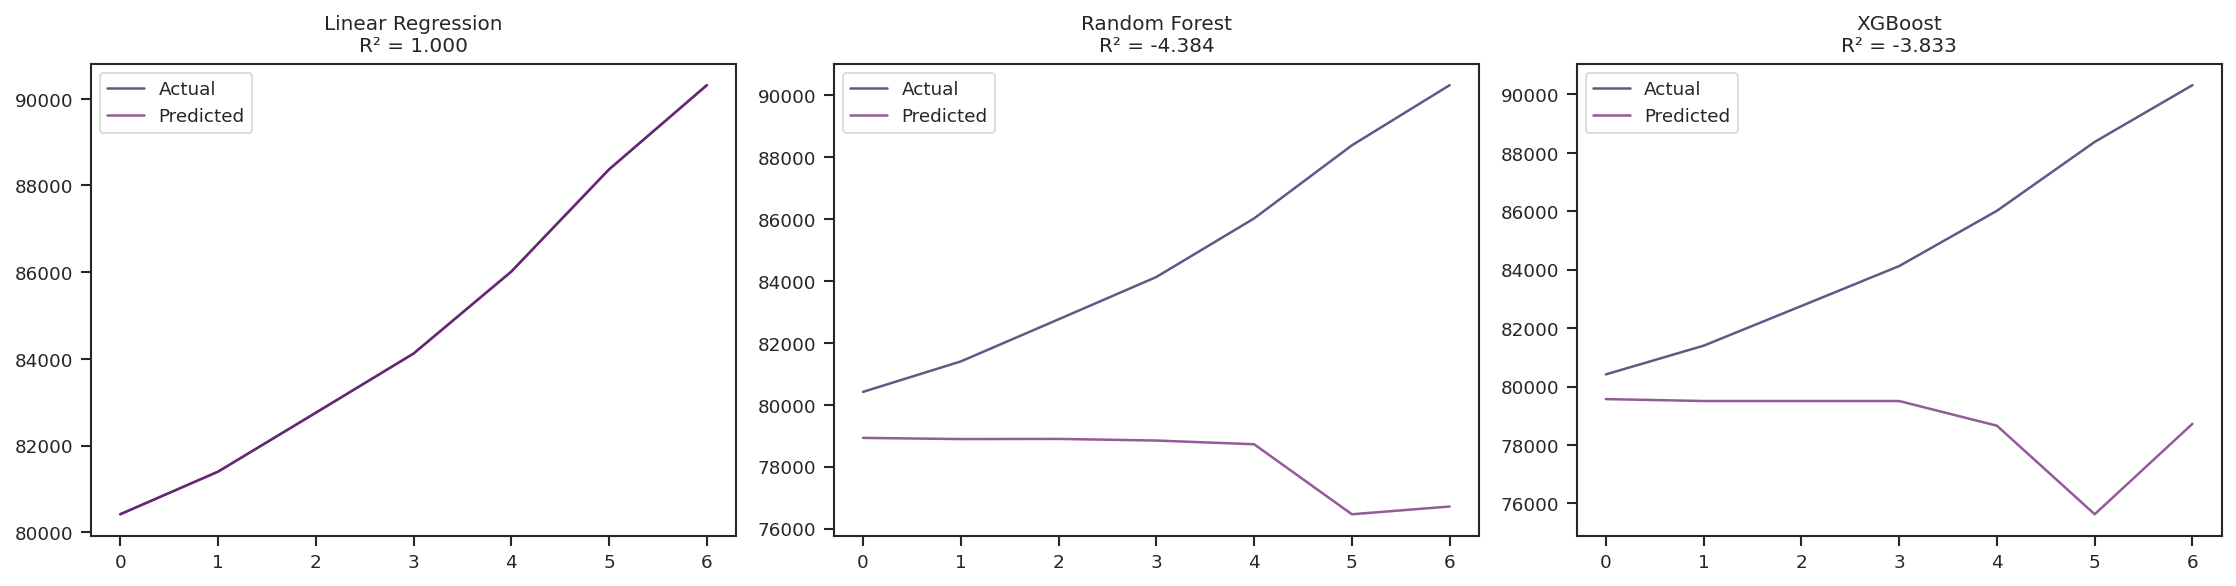

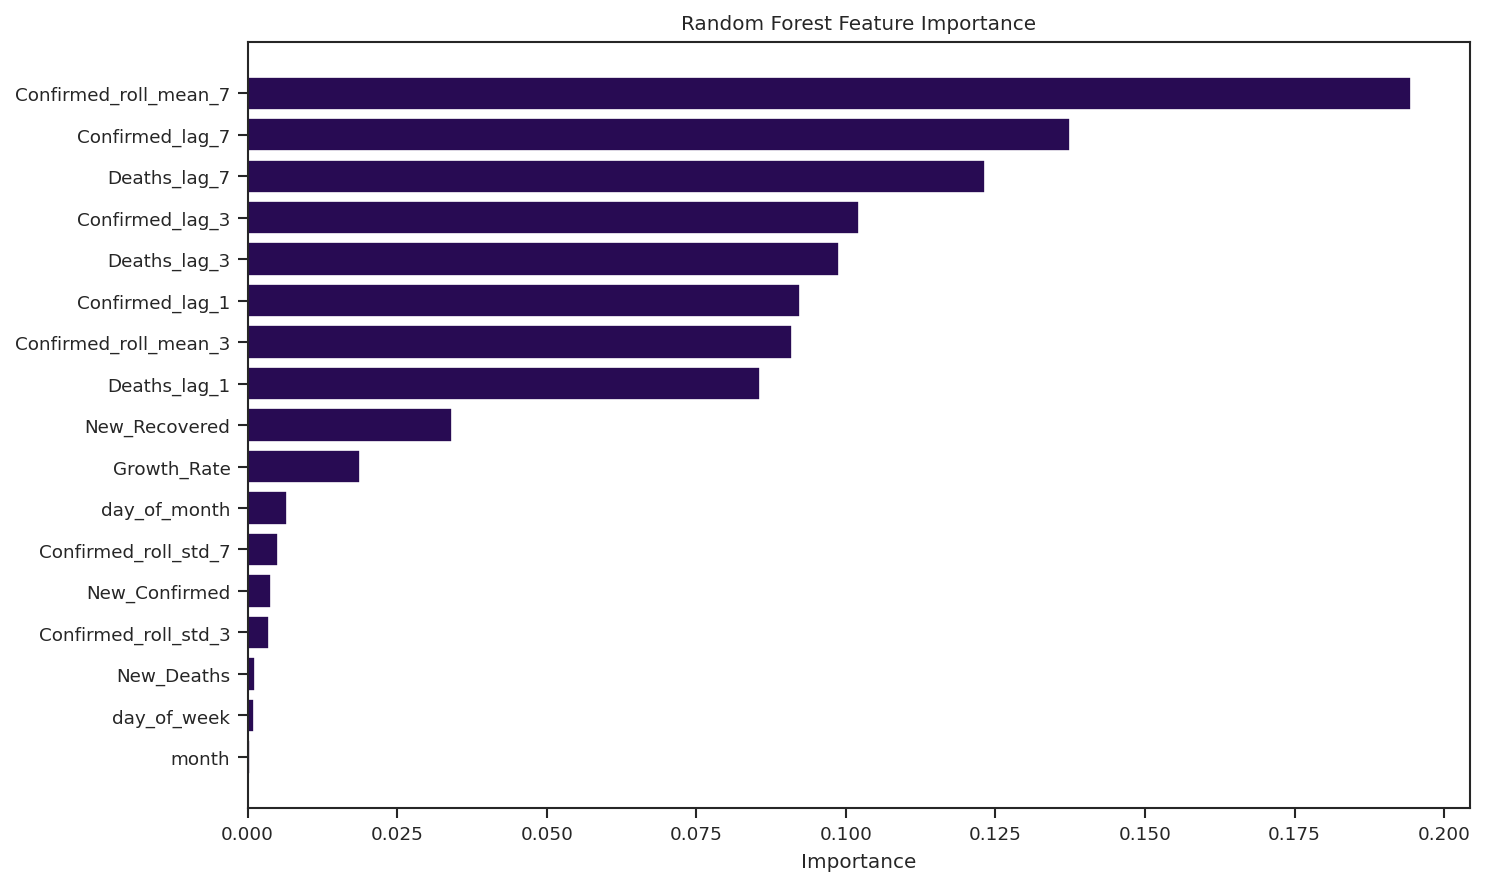

In [28]:
# 6.2 Model training and evaluation
def train_models(X, y, test_size=0.2):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, shuffle=False
    )
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    models = {
        'Linear Regression': LinearRegression(),
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
        'XGBoost': XGBRegressor(n_estimators=100, random_state=42)
    }

    results = {}
    predictions = {}
    for name, model in models.items():
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        predictions[name] = y_pred
        results[name] = {
            'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
            'MAE': mean_absolute_error(y_test, y_pred),
            'R2': r2_score(y_test, y_pred)
        }
        print(f"\n{name} Performance:")
        print(f"  RMSE: {results[name]['RMSE']:,.0f}")
        print(f"  MAE: {results[name]['MAE']:,.0f}")
        print(f"  R²: {results[name]['R2']:.4f}")

    # Plot predictions vs actual
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for idx, (name, y_pred) in enumerate(predictions.items()):
        axes[idx].plot(y_test.values, label='Actual', alpha=0.7)
        axes[idx].plot(y_pred, label='Predicted', alpha=0.7)
        axes[idx].set_title(f'{name}\nR² = {results[name]["R2"]:.3f}')
        axes[idx].legend()
    plt.tight_layout()
    plt.show()

    # Feature importance (Random Forest)
    if 'Random Forest' in models:
        rf = models['Random Forest']
        importance = pd.DataFrame({
            'feature': X.columns,
            'importance': rf.feature_importances_
        }).sort_values('importance', ascending=False)
        plt.figure(figsize=(10,6))
        plt.barh(importance['feature'], importance['importance'])
        plt.xlabel('Importance')
        plt.title('Random Forest Feature Importance')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()

    return results, predictions

X = df_ml[feature_cols]
y = df_ml['Confirmed']
results, predictions = train_models(X, y)

### Comparing Prophet Forecast with Actual Confirmed Cases

In [33]:
# Merge forecast with actual data for plotting
forecast_df = forecast_result.set_index('ds')
actual_df = df_global.set_index('Date')['Confirmed']

# Combine actual and forecasted data for easy plotting
combined_df = pd.DataFrame({
    'Actual Confirmed': actual_df,
    'Forecasted Confirmed': forecast_df['yhat']
}).reset_index()

combined_df = combined_df.rename(columns={'index': 'Date'})

# Create the plot
fig = go.Figure()

# Add actual data trace
fig.add_trace(go.Scatter(x=combined_df['Date'], y=combined_df['Actual Confirmed'],
                         mode='lines+markers', name='Actual Confirmed Cases', line=dict(color='blue')))

# Add forecasted data trace
fig.add_trace(go.Scatter(x=combined_df['Date'], y=combined_df['Forecasted Confirmed'],
                         mode='lines', name='Prophet Forecasted Cases', line=dict(color='red', dash='dash')))

# Add confidence interval if available (from forecast_result)
fig.add_trace(go.Scatter(x=forecast_df.index,
                         y=forecast_df['yhat_upper'],
                         mode='lines',
                         line=dict(width=0), showlegend=False,
                         hoverinfo='skip',
                         fillcolor='rgba(255,0,0,0.1)',
                         fill='tonexty', name='Forecast Confidence Interval'))
fig.add_trace(go.Scatter(x=forecast_df.index,
                         y=forecast_df['yhat_lower'],
                         mode='lines',
                         line=dict(width=0), showlegend=False,
                         hoverinfo='skip',
                         fillcolor='rgba(255,0,0,0.1)',
                         fill='tonexty', name='Forecast Confidence Interval'))

# Update layout
fig.update_layout(
    title='Actual vs. Prophet Forecasted Global Confirmed Cases',
    xaxis_title='Date',
    yaxis_title='Confirmed Cases',
    hovermode='x unified',
    height=600
)

fig.show()

## 7. Advanced Geospatial Analysis

In [25]:
# Interactive Folium map
def create_folium_map(df, date=None):
    if date is None:
        date = df['Date'].max()
    df_map = df[df['Date'] == date].copy()
    df_map = df_map.groupby(['Country/Region', 'Lat', 'Long']).agg({
        'Confirmed': 'sum', 'Deaths': 'sum', 'Recovered': 'sum'
    }).reset_index()
    m = folium.Map(location=[20, 0], zoom_start=2, tiles='CartoDB positron')
    for _, row in df_map.iterrows():
        if row['Confirmed'] > 0:
            radius = np.sqrt(row['Confirmed']) * 0.5
            popup = f"""
            <b>{row['Country/Region']}</b><br>
            Confirmed: {row['Confirmed']:,.0f}<br>
            Deaths: {row['Deaths']:,.0f}<br>
            Recovered: {row['Recovered']:,.0f}
            """
            folium.CircleMarker(
                location=[row['Lat'], row['Long']],
                radius=min(radius, 30),
                popup=popup,
                color='red', fill=True, fillColor='red', fillOpacity=0.6
            ).add_to(m)
    return m

covid_map = create_folium_map(df)
covid_map.save('covid19_global_map.html')
print("Map saved as 'covid19_global_map.html'")
display(covid_map)

Map saved as 'covid19_global_map.html'


## 8. Spread Dynamics Analysis

In [20]:
# Doubling time calculation
def doubling_time(series):
    growth = series.pct_change().dropna()
    growth = growth[growth > 0]
    if len(growth) == 0:
        return np.inf
    avg_growth = growth.mean()
    return np.log(2) / np.log(1 + avg_growth)

countries = df['Country/Region'].unique()
dt_data = []
for country in countries:
    data = df[df['Country/Region'] == country].groupby('Date')['Confirmed'].sum()
    if len(data) > 7 and data.iloc[-1] > 100:
        dt = doubling_time(data)
        if dt < 100:
            dt_data.append({'Country': country, 'Doubling_Time_Days': dt, 'Total': data.iloc[-1]})

df_dt = pd.DataFrame(dt_data).sort_values('Doubling_Time_Days')
print("Countries with shortest doubling time (fastest spread):")
df_dt.head(10)

Countries with shortest doubling time (fastest spread):


,Country,Doubling_Time_Days,Total
7,Italy,0,2036
6,Germany,0,159
5,France,0,191
4,Singapore,0,108
9,Ship Diamond Princess,0,705
10,Iran,0,1501
8,Spain,0,120
2,South Korea,2,4335
3,United States,2,105
1,Japan,3,274


In [29]:
# Outbreak stage classification
def classify_stage(confirmed):
    if confirmed < 100: return 'Early'
    elif confirmed < 1000: return 'Community Spread'
    elif confirmed < 10000: return 'Widespread'
    elif confirmed < 100000: return 'Severe'
    else: return 'Critical'

df_latest['Stage'] = df_latest['Confirmed'].apply(classify_stage)
stage_counts = df_latest['Stage'].value_counts()

fig = px.pie(values=stage_counts.values, names=stage_counts.index,
             title='Outbreak Stage Distribution',
             color_discrete_sequence=px.colors.sequential.Reds_r)
fig.show()



## 9. Summary Report

In [30]:
def generate_summary(df, df_global, df_latest):
    latest = df_global.iloc[-1]
    summary = f"""
    ========================================
        COVID-19 Analysis Summary
    ========================================

    Date range: {df['Date'].min()} to {df['Date'].max()}
    Countries/regions: {df['Country/Region'].nunique()}
    Total records: {len(df):,}

    Latest global figures ({latest['Date'].strftime('%Y-%m-%d')}):
    ----------------------------------------
    Confirmed: {latest['Confirmed']:,.0f}
    Deaths: {latest['Deaths']:,.0f}
    Recovered: {latest['Recovered']:,.0f}
    Active: {latest['Active']:,.0f}
    Death Rate: {(latest['Deaths']/latest['Confirmed']*100):.2f}%
    Recovery Rate: {(latest['Recovered']/latest['Confirmed']*100):.2f}%

    Top 5 affected countries:
    ----------------------------------------
    """
    for _, row in df_latest.head(5).iterrows():
        summary += f"    {row['Country/Region']}: {row['Confirmed']:,.0f} cases, {row['Death_Rate']:.1f}% fatality\n"
    summary += "\n    ========================================\n"
    return summary

print(generate_summary(df, df_global, df_latest))


        COVID-19 Analysis Summary
    
    Date range: 2020-01-22 00:00:00 to 2020-03-02 00:00:00
    Countries/regions: 75
    Total records: 5,822
    
    Latest global figures (2020-03-02):
    ----------------------------------------
    Confirmed: 90,313
    Deaths: 3,085
    Recovered: 45,604
    Active: 41,624
    Death Rate: 3.42%
    Recovery Rate: 50.50%
    
    Top 5 affected countries:
    ----------------------------------------
        China: 80,026 cases, 3.6% fatality
    South Korea: 4,335 cases, 0.6% fatality
    Italy: 2,036 cases, 2.6% fatality
    Iran: 1,501 cases, 4.4% fatality
    Ship Diamond Princess: 705 cases, 0.9% fatality




## 10. Export Results

In [31]:
df_global.to_csv('covid19_global_daily.csv', index=False)
df_latest.to_csv('covid19_country_latest.csv', index=False)
print("Exported:")
print("  - covid19_global_daily.csv")
print("  - covid19_country_latest.csv")

print("\nLibrary versions:")
print(f"  Pandas: {pd.__version__}")
print(f"  NumPy: {np.__version__}")
print(f"  Matplotlib: {mpl.__version__}")
print(f"  Seaborn: {sns.__version__}")
print(f"  Plotly: {plotly.__version__}")

Exported:
  - covid19_global_daily.csv
  - covid19_country_latest.csv

Library versions:
  Pandas: 2.2.3
  NumPy: 2.1.3
  Matplotlib: 3.10.0
  Seaborn: 0.13.2
  Plotly: 5.24.1
